# Stage 7 Fix — Baseline Comparison + Anomaly Fusion
## PS1: Parking-Induced Congestion — Bengaluru

This notebook closes two gaps identified in review of Stage 7:

1. **No naive baseline comparison existed** — without one, there's no
   answer ready for "why not just sort by violation count?" This builds
   that comparison explicitly.
2. **`anomaly_rate` (from the Stage 4 Isolation Forest) was computed but
   never used downstream** — a trained model sitting unused. This fuses it
   into the Priority Score as a deliberate fourth component, not a bolt-on.




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
"""
Recovery Fix — Restore anomaly_rate into cluster_summary_fixed.csv
=====================================================================
Root cause: anomaly_rate was correctly computed and merged in Stage 4's
notebook, but saved into a DIFFERENT cluster_summary.csv than the one that
later went through the OSMnx merge (cluster_summary_updated.csv ->
cluster_summary_fixed.csv). Two parallel file branches, never joined.

This script regenerates anomaly_rate from Stage 4's saved daily feature
table (cluster_day_anomaly_scores.csv) -- no need to retrain the Isolation
Forest -- and merges it into your CURRENT, correct file
(cluster_summary_fixed.csv), which already has the percentile-fixed
persistence classification AND the OSMnx road_importance data.

Input  : cluster_summary_fixed.csv          (current correct file)
         cluster_day_anomaly_scores.csv     (Stage 4 daily anomaly output)
Output : cluster_summary_fixed.csv          (overwritten, now with anomaly_rate)
"""

import pandas as pd
import os

CURRENT_FILE = "/content/drive/MyDrive/gridlock_flipkart/cluster_summary_fixed.csv"
DAILY_ANOMALY_FILE = "/content/drive/MyDrive/gridlock_flipkart/cluster_day_anomaly_scores.csv"

print("=" * 60)
print("RECOVERY: Restoring anomaly_rate")
print("=" * 60)

cs = pd.read_csv(CURRENT_FILE)
print(f"\nLoaded current file: {cs.shape}")
print(f"  anomaly_rate already present? {'anomaly_rate' in cs.columns}")

if "anomaly_rate" in cs.columns:
    print("\n  Nothing to do -- anomaly_rate already exists in this file.")
else:
    if not os.path.exists(DAILY_ANOMALY_FILE):
        raise FileNotFoundError(
            f"\n  '{DAILY_ANOMALY_FILE}' not found in the working directory.\n"
            f"  This is the per-cluster-per-day output saved by Stage 4's\n"
            f"  notebook (the cell right after Isolation Forest training).\n"
            f"  Locate it in your Drive folder from that Colab run and\n"
            f"  upload/copy it next to this script, then re-run."
        )

    daily = pd.read_csv(DAILY_ANOMALY_FILE)
    print(f"\nLoaded daily anomaly table: {daily.shape}")
    print(f"  Columns: {daily.columns.tolist()}")

    assert "is_anomaly" in daily.columns, (
        "Expected an 'is_anomaly' column in the daily anomaly table -- "
        "check this is really Stage 4's output, not some other file."
    )

    # Re-aggregate exactly as Stage 4 did: anomaly_rate = mean(is_anomaly) per cluster
    cluster_anomaly_rate = (
        daily.groupby("cluster_id")["is_anomaly"]
        .mean()
        .reset_index(name="anomaly_rate")
    )

    print(f"\nRecomputed anomaly_rate for {len(cluster_anomaly_rate)} clusters")
    print(cluster_anomaly_rate.sort_values("anomaly_rate", ascending=False).head(10))

    # Merge into the CURRENT correct file
    before_cols = cs.shape[1]
    cs = cs.merge(cluster_anomaly_rate, on="cluster_id", how="left")

    missing = cs["anomaly_rate"].isna().sum()
    if missing > 0:
        print(f"\n  WARNING: {missing} clusters had no match in the daily "
              f"anomaly table -- check cluster_id alignment between files.")

    print(f"\nShape: {before_cols} cols -> {cs.shape[1]} cols")

    cs.to_csv(CURRENT_FILE, index=False)
    print(f"\nSaved (overwritten): {CURRENT_FILE}")
    print(f"  Final shape: {cs.shape}")
    print(f"  anomaly_rate now present: {'anomaly_rate' in cs.columns}")

print("\n" + "=" * 60)
print("Next step: re-run the Stage 7 fix notebook's fusion cells -- ")
print("they will now find anomaly_rate already in cluster_summary_fixed.csv")
print("and the fallback-merge code path won't even trigger.")
print("=" * 60)

RECOVERY: Restoring anomaly_rate

Loaded current file: (30, 39)
  anomaly_rate already present? False

Loaded daily anomaly table: (2909, 10)
  Columns: ['cluster_id', 'date', 'violations_count', 'avg_severity', 'junction_pct', 'avg_vehicle_weight', 'multi_violation_pct', 'violations_per_hour_std', 'anomaly_score', 'is_anomaly']

Recomputed anomaly_rate for 30 clusters
    cluster_id  anomaly_rate
5            5      0.321839
6            6      0.214286
2            2      0.157895
4            4      0.154639
12          12      0.120000
0            0      0.097826
15          15      0.049505
29          29      0.045455
7            7      0.043860
27          27      0.038835

Shape: 39 cols -> 40 cols

Saved (overwritten): /content/drive/MyDrive/gridlock_flipkart/cluster_summary_fixed.csv
  Final shape: (30, 40)
  anomaly_rate now present: True

Next step: re-run the Stage 7 fix notebook's fusion cells -- 
they will now find anomaly_rate already in cluster_summary_fixed.csv
and 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

cs = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_priority_ranking.csv")
print(f"Loaded {cs.shape[0]} clusters, {cs.shape[1]} columns")
print(f"\n'anomaly_rate' present: {'anomaly_rate' in cs.columns}")

Loaded 30 clusters, 52 columns

'anomaly_rate' present: False


In [18]:
# If anomaly_rate is missing from this file, pull it in from an earlier
# Stage 4 output that has it. Update the path below if your file is named
# differently or sits elsewhere in Drive.
if "anomaly_rate" not in cs.columns:
    stage4_source = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_fixed.csv")   # <-- update path if needed
    assert "anomaly_rate" in stage4_source.columns, (
        "anomaly_rate not found in cluster_summary.csv either -- "
        "check the Stage 4 notebook output file name/path"
    )
    cs = cs.merge(
        stage4_source[["cluster_id", "anomaly_rate"]],
        on="cluster_id", how="left"
    )
    print("Merged anomaly_rate in from Stage 4 output.")

print(cs["anomaly_rate"].describe())

Merged anomaly_rate in from Stage 4 output.
count    30.000000
mean      0.052894
std       0.072928
min       0.000000
25%       0.016951
50%       0.021762
75%       0.045056
max       0.321839
Name: anomaly_rate, dtype: float64


## 1. Naive baseline comparison

The simplest possible "intelligence": just rank zones by raw violation
count. This is what a non-AI, status-quo approach would produce — and what
any judge's first instinct will be to compare against.

We build three columns side by side:
- **Naive rank** — sort by `size` (violation count) alone
- **Impact rank** — sort by `congestion_impact_index` alone (Stage 6)
- **Priority rank** — the full multi-stage pipeline output (Stage 7)


In [19]:
cs["naive_rank"]    = cs["size"].rank(ascending=False)
cs["impact_rank"]   = cs["congestion_impact_index"].rank(ascending=False)
cs["priority_rank"] = cs["priority_score"].rank(ascending=False)

baseline_compare = cs[["cluster_id", "top_station", "size",
                       "congestion_impact_index", "priority_score",
                       "naive_rank", "impact_rank", "priority_rank"]]\
    .sort_values("priority_rank")

baseline_compare.head(10)

,cluster_id,top_station,size,congestion_impact_index,priority_score,naive_rank,impact_rank,priority_rank
21,28,Upparpet,1972,47.42,100.00,22.0,3.0,1.0
24,18,Rajajinagar,1721,41.08,31.24,25.0,5.0,2.0
7,21,Malleshwaram,3436,46.26,29.72,8.0,4.0,3.0
12,23,Shivajinagar,2514,32.01,24.71,13.0,12.0,4.0
23,3,K.R. Pura,1789,29.15,24.28,24.0,20.0,5.0
5,20,Malleshwaram,4068,29.81,18.44,6.0,18.0,6.0
6,24,Shivajinagar,3603,24.67,17.38,7.0,25.0,7.0
29,17,Pulikeshinagar(F.Town),1379,22.45,17.19,30.0,28.0,8.0
20,5,HAL Old Airport,1988,53.42,16.94,21.0,1.0,9.0
14,19,Halasur,2374,30.86,14.17,15.0,14.0,10.0


## 2. Where the naive baseline actually fails

The clearest way to show the pipeline adds value: find zones where naive
(violation-count) ranking and final priority ranking disagree sharply, and
explain why in plain terms.


In [20]:
baseline_compare["naive_vs_priority_shift"] = (
    baseline_compare["naive_rank"] - baseline_compare["priority_rank"]
)

biggest_shifts = baseline_compare.sort_values(
    "naive_vs_priority_shift", key=abs, ascending=False
).head(8)

print("Zones where naive (volume-only) ranking and final priority disagree most:")
biggest_shifts[["cluster_id", "top_station", "size", "priority_score",
               "naive_rank", "priority_rank", "naive_vs_priority_shift"]]

Zones where naive (volume-only) ranking and final priority disagree most:


,cluster_id,top_station,size,priority_score,naive_rank,priority_rank,naive_vs_priority_shift
24,18,Rajajinagar,1721,31.24,25.0,2.0,23.0
1,7,HSR Layout,5264,3.93,2.0,25.0,-23.0
29,17,Pulikeshinagar(F.Town),1379,17.19,30.0,8.0,22.0
21,28,Upparpet,1972,100.00,22.0,1.0,21.0
2,25,City Market,4879,5.20,3.0,24.0,-21.0
23,3,K.R. Pura,1789,24.28,24.0,5.0,19.0
3,11,Malleshwaram,4338,7.65,4.0,21.0,-17.0
0,29,Upparpet,8292,12.16,1.0,14.0,-13.0


In [21]:
# Concrete example: the single biggest case
example = biggest_shifts.iloc[0]
print(f"Example -- Cluster {int(example['cluster_id'])} ({example['top_station']}):")
print(f"  Violation count    : {int(example['size'])} "
      f"(naive rank #{int(example['naive_rank'])})")
print(f"  Final priority rank: #{int(example['priority_rank'])}")
print(f"  Shift              : {int(example['naive_vs_priority_shift'])} positions")
print()
print("This is the concrete answer to 'why not just sort by violation count':")
print("naive ranking would have sent enforcement to a high-volume zone that")
print("is actually lower priority once persistence and time-predictability")
print("are accounted for -- or missed a lower-volume zone that's a")
print("consistent, predictable problem.")

Example -- Cluster 18 (Rajajinagar):
  Violation count    : 1721 (naive rank #25)
  Final priority rank: #2
  Shift              : 23 positions

This is the concrete answer to 'why not just sort by violation count':
naive ranking would have sent enforcement to a high-volume zone that
is actually lower priority once persistence and time-predictability
are accounted for -- or missed a lower-volume zone that's a
consistent, predictable problem.


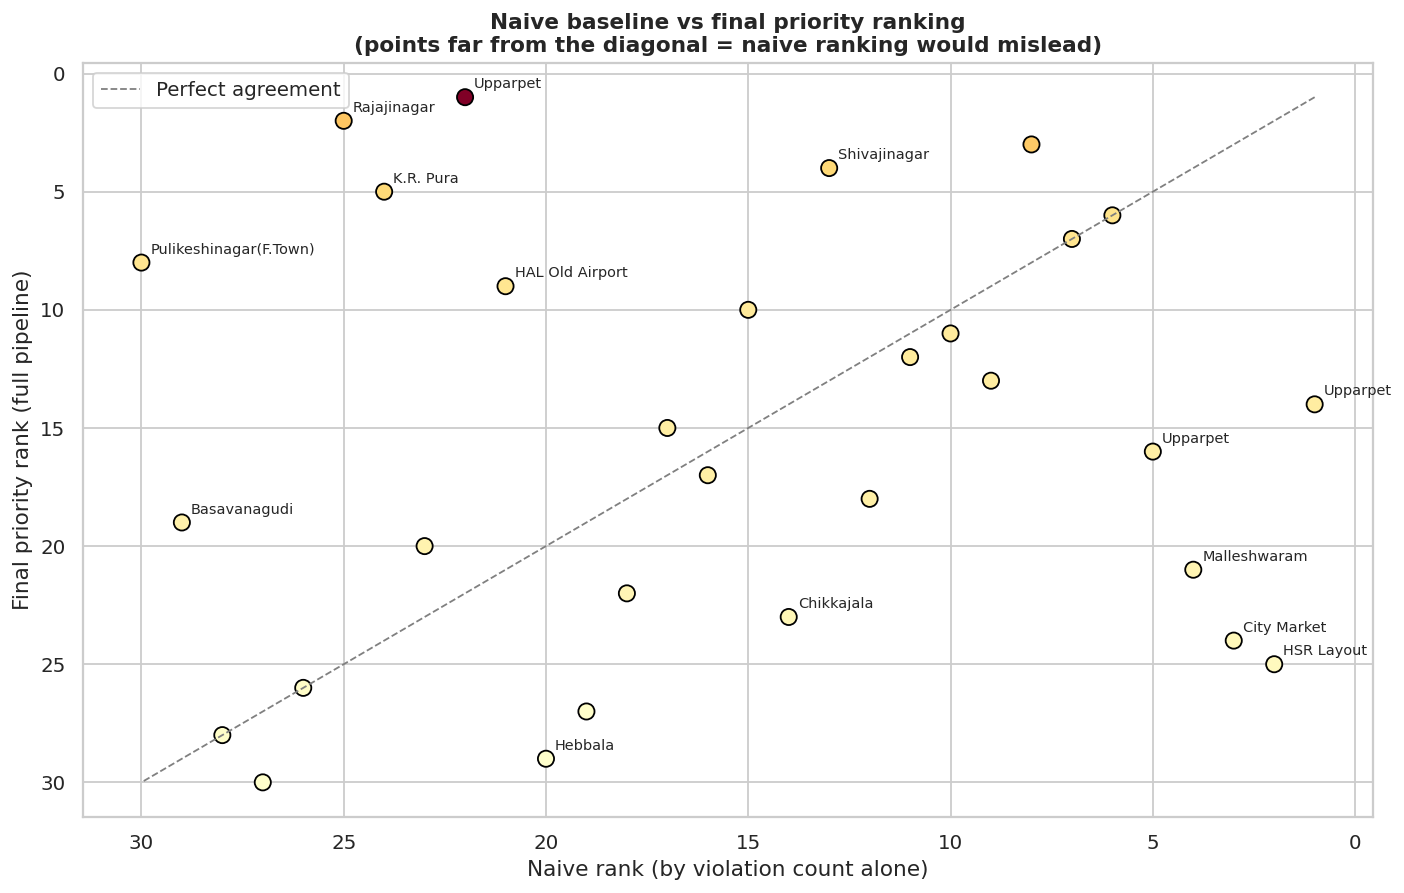

In [22]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(cs["naive_rank"], cs["priority_rank"], s=80,
           c=cs["priority_score"], cmap="YlOrRd", edgecolors="black")

for _, row in cs.iterrows():
    if abs(row["naive_rank"] - row["priority_rank"]) > 8:
        ax.annotate(row["top_station"],
                    (row["naive_rank"], row["priority_rank"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.plot([1, 30], [1, 30], color="gray", ls="--", lw=1, label="Perfect agreement")
ax.set_xlabel("Naive rank (by violation count alone)")
ax.set_ylabel("Final priority rank (full pipeline)")
ax.set_title("Naive baseline vs final priority ranking\n"
             "(points far from the diagonal = naive ranking would mislead)",
             fontweight="bold")
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("s7fix_baseline_vs_priority.png")
plt.show()

## 3. Fusing anomaly_rate — as a deliberate fourth component

`anomaly_rate` measures day-to-day instability (Stage 4, Isolation Forest) —
conceptually different from impact, persistence, or time risk. It doesn't
say a zone is bad, it says a zone is **unpredictable**, which matters
operationally: a consistently bad zone can be scheduled for; an unstable one
needs flexible/responsive capacity instead of fixed scheduling.

Rather than quietly blending it into the same multiplicative formula (which
would muddy what each component means), it's added as a **separate
modifier**: a small bonus added after the core Priority Score, scaled so it
can meaningfully break ties among similar-priority zones but never
override a real priority gap on its own.

```
final_priority = priority_score + (anomaly_rate_normalized * 10)
```

The `* 10` cap means anomaly_rate can shift a cluster by at most 10 points
on the 0-100 priority scale -- enough to matter, not enough to dominate.


In [23]:
anomaly_scaler = MinMaxScaler()
cs["anomaly_rate_norm"] = anomaly_scaler.fit_transform(cs[["anomaly_rate"]])

ANOMALY_BONUS_CAP = 10

cs["final_priority_score"] = (
    cs["priority_score"] + cs["anomaly_rate_norm"] * ANOMALY_BONUS_CAP
)

# Rescale back to 0-100 for readability
cs["final_priority_score"] = (
    (cs["final_priority_score"] - cs["final_priority_score"].min())
    / (cs["final_priority_score"].max() - cs["final_priority_score"].min())
    * 100
).round(2)

final_ranked = cs[["cluster_id", "top_station", "priority_score",
                   "anomaly_rate", "anomaly_rate_norm",
                   "final_priority_score"]]\
    .sort_values("final_priority_score", ascending=False)

final_ranked.head(10)

,cluster_id,top_station,priority_score,anomaly_rate,anomaly_rate_norm,final_priority_score
21,28,Upparpet,100.00,0.011111,0.034524,100.00
24,18,Rajajinagar,31.24,0.020619,0.064065,31.43
7,21,Malleshwaram,29.72,0.000000,0.000000,29.26
20,5,HAL Old Airport,16.94,0.321839,1.000000,26.48
12,23,Shivajinagar,24.71,0.000000,0.000000,24.25
23,3,K.R. Pura,24.28,0.009804,0.030462,24.12
8,6,HAL Old Airport,12.33,0.214286,0.665816,18.52
5,20,Malleshwaram,18.44,0.000000,0.000000,17.97
6,24,Shivajinagar,17.38,0.019608,0.060924,17.52
29,17,Pulikeshinagar(F.Town),17.19,0.022472,0.069823,17.41


## 4. Validate the fusion didn't overwhelm the core ranking

Check the rank correlation between the pre-fusion Priority Score and the
post-fusion Final Priority Score. High correlation confirms anomaly_rate is
acting as a modifier, not replacing the core logic.


In [24]:
corr, _ = spearmanr(cs["priority_score"], cs["final_priority_score"])
print(f"Spearman correlation: priority_score vs final_priority_score = {corr:.4f}")
print(f"(Should be high -- anomaly_rate should refine, not override, the ranking)")

cs["fusion_rank_shift"] = cs["priority_score"].rank(ascending=False) - \
                          cs["final_priority_score"].rank(ascending=False)

biggest_fusion_shifts = cs.sort_values("fusion_rank_shift", key=abs, ascending=False).head(5)
print("\nClusters most affected by the anomaly_rate fusion:")
biggest_fusion_shifts[["cluster_id", "top_station", "anomaly_rate",
                       "priority_score", "final_priority_score",
                       "fusion_rank_shift"]]

Spearman correlation: priority_score vs final_priority_score = 0.9746
(Should be high -- anomaly_rate should refine, not override, the ranking)

Clusters most affected by the anomaly_rate fusion:


,cluster_id,top_station,anomaly_rate,priority_score,final_priority_score,fusion_rank_shift
8,6,HAL Old Airport,0.214286,12.33,18.52,6.0
20,5,HAL Old Airport,0.321839,16.94,26.48,5.0
14,19,Halasur,0.020202,14.17,14.32,-3.0
22,12,Byatarayanapura,0.120000,8.39,11.64,3.0
6,24,Shivajinagar,0.019608,17.38,17.52,-2.0


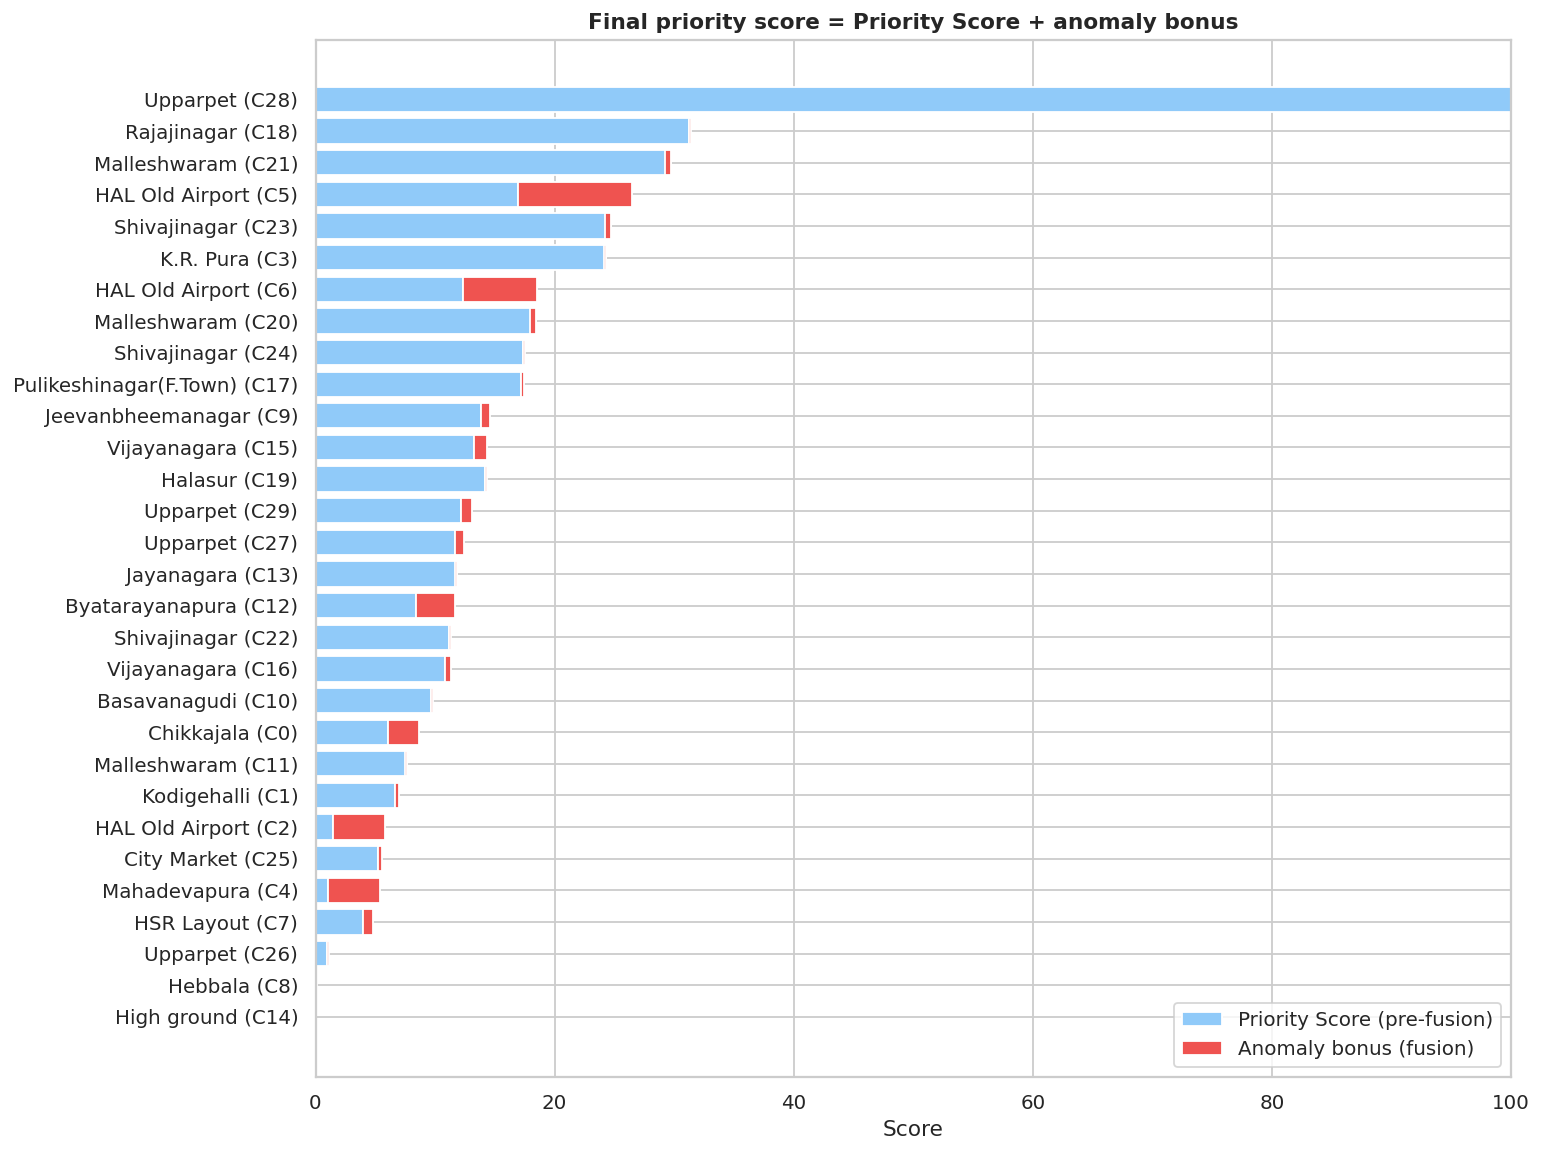

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))

ordered = cs.sort_values("final_priority_score", ascending=True)
ax.barh(ordered["top_station"] + " (C" + ordered["cluster_id"].astype(str) + ")",
        ordered["priority_score"], color="#90CAF9", label="Priority Score (pre-fusion)")
ax.barh(ordered["top_station"] + " (C" + ordered["cluster_id"].astype(str) + ")",
        ordered["final_priority_score"] - ordered["priority_score"],
        left=ordered["priority_score"], color="#EF5350",
        label="Anomaly bonus (fusion)")

ax.set_xlabel("Score")
ax.set_title("Final priority score = Priority Score + anomaly bonus",
             fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("s7fix_anomaly_fusion.png")
plt.show()

## 5. Save outputs

In [27]:
cs.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_priority_final.csv", index=False)
baseline_compare.to_csv("/content/drive/MyDrive/gridlock_flipkart/baseline_comparison.csv", index=False)

print("Saved:")
print("  cluster_priority_final.csv  —", cs.shape)
print("  baseline_comparison.csv     —", baseline_compare.shape)
print()
print("Final top 5 (after baseline validation + anomaly fusion):")
print(final_ranked.head(5)[["cluster_id", "top_station", "final_priority_score"]]
      .to_string(index=False))

Saved:
  cluster_priority_final.csv  — (30, 57)
  baseline_comparison.csv     — (30, 9)

Final top 5 (after baseline validation + anomaly fusion):
 cluster_id     top_station  final_priority_score
         28        Upparpet                100.00
         18     Rajajinagar                 31.43
         21    Malleshwaram                 29.26
          5 HAL Old Airport                 26.48
         23    Shivajinagar                 24.25
